In [ ]:
import os
from pathlib import Path
import shutil
from google.colab import drive
import zipfile

In [ ]:
drive.mount('/content/drive')

ZIP_FILE_PATH = '/content/drive/MyDrive/project-3-at-2026-03-20-10-48-39de0f04.zip'
WORKING_DIR = '/content/pallet_data'
OUTPUT_MODEL_DIR = '/content/drive/MyDrive/pallet_model'

# Create working directory
os.makedirs(WORKING_DIR, exist_ok=True)

# Unzip the dataset
with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
    zip_ref.extractall(WORKING_DIR)

Mounted at /content/drive


In [ ]:
import os
import shutil

path_to_folder_delete = '/content/pallet_data'

# remove an empty directory
shutil.rmtree(path_to_folder_delete)      # throws OSError if not empty


In [ ]:
import random

# Paths
dataset_path = WORKING_DIR
image_dir = os.path.join(dataset_path, "images")
label_dir = os.path.join(dataset_path, "labels")

# Output paths
train_img = os.path.join(dataset_path, "images/train")
val_img = os.path.join(dataset_path, "images/val")
train_lbl = os.path.join(dataset_path, "labels/train")
val_lbl = os.path.join(dataset_path, "labels/val")

# Create train/val folders
for d in [train_img, val_img, train_lbl, val_lbl]:
    os.makedirs(d, exist_ok=True)

# List images and shuffle
images = sorted([f for f in os.listdir(image_dir) if f.endswith(".png")])  # Adjust for other image formats
random.shuffle(images)

# Split 80% train, 20% val
split_idx = int(0.8 * len(images))
train_files, val_files = images[:split_idx], images[split_idx:]

# Move files
for file_list, img_dest, lbl_dest in [(train_files, train_img, train_lbl), (val_files, val_img, val_lbl)]:
    for file in file_list:
        shutil.move(os.path.join(image_dir, file), os.path.join(img_dest, file))
        label_file = file.replace(".png", ".txt")  # Assuming YOLO format
        if os.path.exists(os.path.join(label_dir, label_file)):
            shutil.move(os.path.join(label_dir, label_file), os.path.join(lbl_dest, label_file))

print("Dataset successfully split into training and validation sets!")

Dataset successfully split into training and validation sets!


In [ ]:
# Read class names from classes.txt
classes_txt_path = os.path.join(dataset_path, "classes.txt")
with open(classes_txt_path, "r") as f:
    class_names = [line.strip() for line in f.readlines()]

# Generate dataset.yaml
dataset_yaml_path = os.path.join(dataset_path, "dataset.yaml")
with open(dataset_yaml_path, "w") as f:
    f.write(f"train: {os.path.join(dataset_path, 'images/train')}\n")
    f.write(f"val: {os.path.join(dataset_path, 'images/val')}\n")
    f.write(f"nc: {len(class_names)}\n")
    f.write(f"names: {class_names}\n")

print('\nFile contents:\n')
!cat /content/pallet_data/dataset.yaml


File contents:

train: /content/pallet_data/images/train
val: /content/pallet_data/images/val
nc: 4
names: ['blue', 'epal', 'nlp', 'nlp_1_2']


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.9 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
#model.train(data=dataset_yaml_path, epochs=100, imgsz=640)

model.train(
    data=dataset_yaml_path,
    epochs=100,
    imgsz=640,
    save_period=10
)

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pallet_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, persp

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fda9bc22630>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
from ultralytics import YOLO

# Load your trained model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Continue training with new parameters
results = model.train(
    data=dataset_yaml_path,
    epochs=20,              # Additional epochs
    imgsz=640,
    save_period=10
)

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pallet_data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/train/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

In [ ]:
results = model.predict(source="/content/pallet_data/images/val", save=True)


image 1/21 /content/pallet_data/images/val/0126d086-back_left_color_img_66askovest.png: 384x640 1 epal, 16.7ms
image 2/21 /content/pallet_data/images/val/1a6fd89d-back_color_img_201.png: 544x640 1 epal, 17.6ms
image 3/21 /content/pallet_data/images/val/2262bffc-hedmarkback_color_img_131.png: 384x640 1 nlp_1_2, 8.7ms
image 4/21 /content/pallet_data/images/val/2b71573d-front_right_color_img_138askovest.png: 384x640 1 epal, 8.2ms
image 5/21 /content/pallet_data/images/val/2da6bbb1-front_left_color_img_35_-_Copy_2.png: 416x640 1 nlp, 17.3ms
image 6/21 /content/pallet_data/images/val/44c60177-front_right_color_img_144.png: 544x640 1 epal, 9.4ms
image 7/21 /content/pallet_data/images/val/621ab07c-back_left_color_img_118askovest.png: 384x640 1 epal, 10.3ms
image 8/21 /content/pallet_data/images/val/66e2ffd6-front_right_color_img_24.png: 384x640 1 epal, 8.1ms
image 9/21 /content/pallet_data/images/val/84bbb203-hedmarkback_color_img_789.png: 384x640 1 nlp_1_2, 8.1ms
image 10/21 /content/pallet

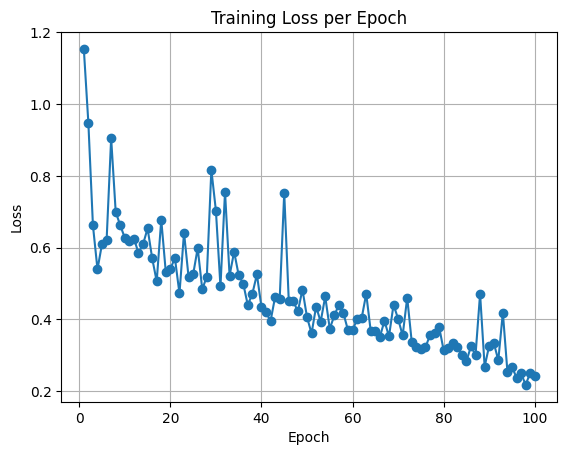

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Locate your run folder, e.g. runs/train/exp
csv_path = "runs/detect/train3/results.csv"
df = pd.read_csv(csv_path)

# 2) Plot total loss per epoch
#    (Ultralytics logs `metrics/xy_loss` + `/obj_loss` + `/cls_loss` = metrics/loss)
plt.plot(df['epoch'], df['train/box_loss'], marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch')
plt.grid(True)
plt.show()

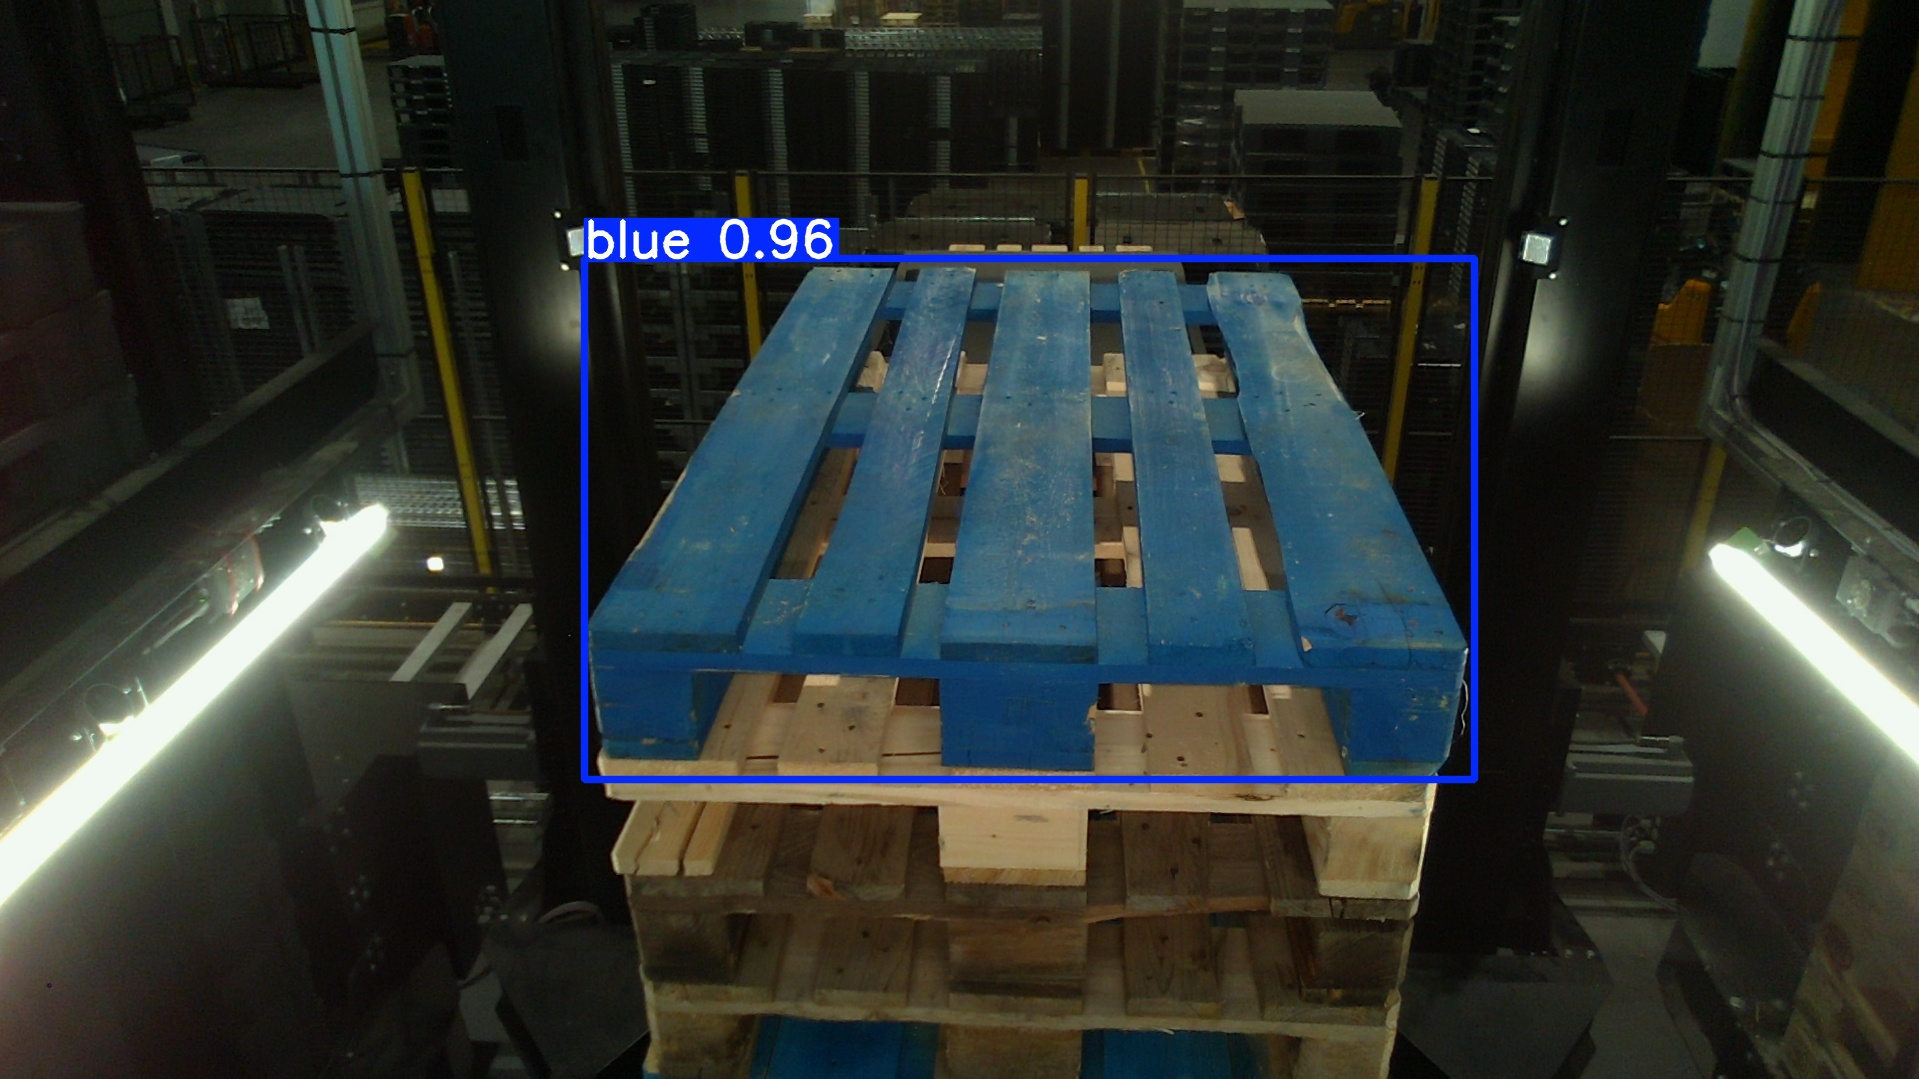

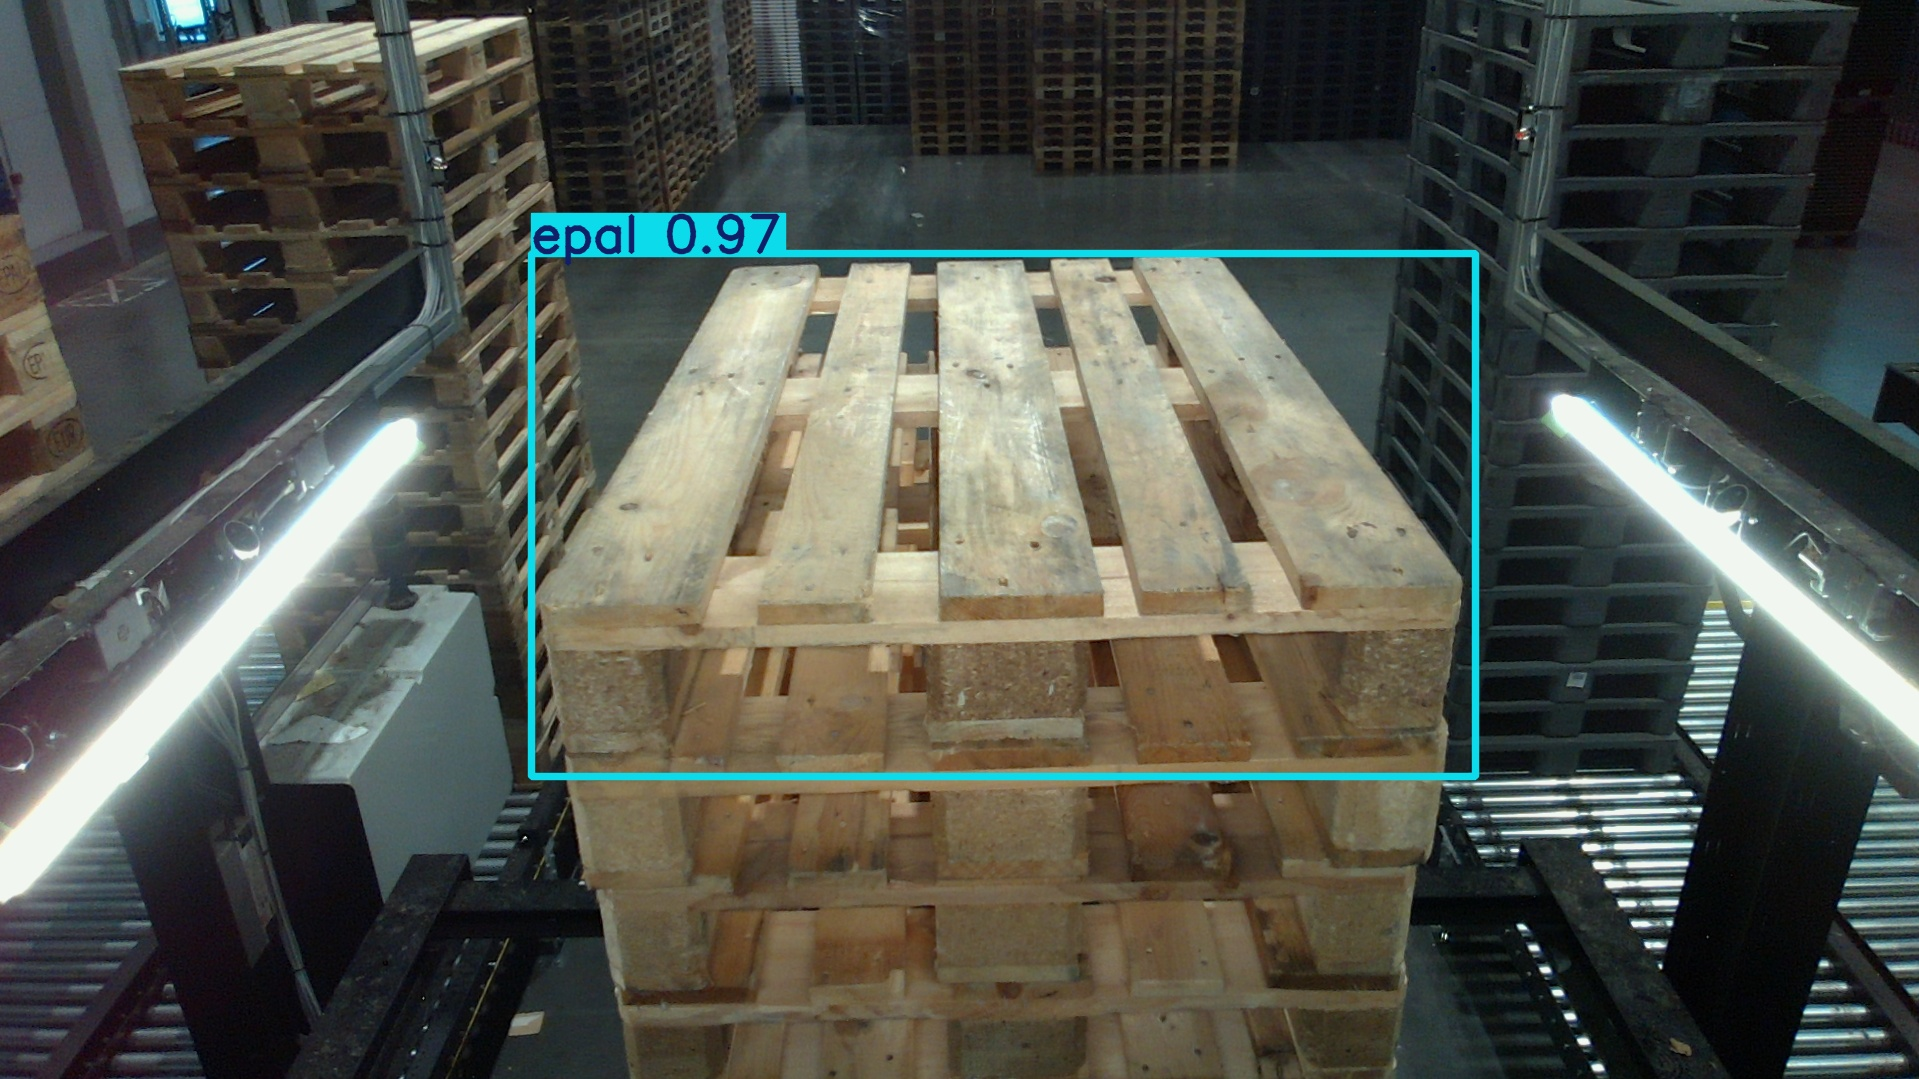

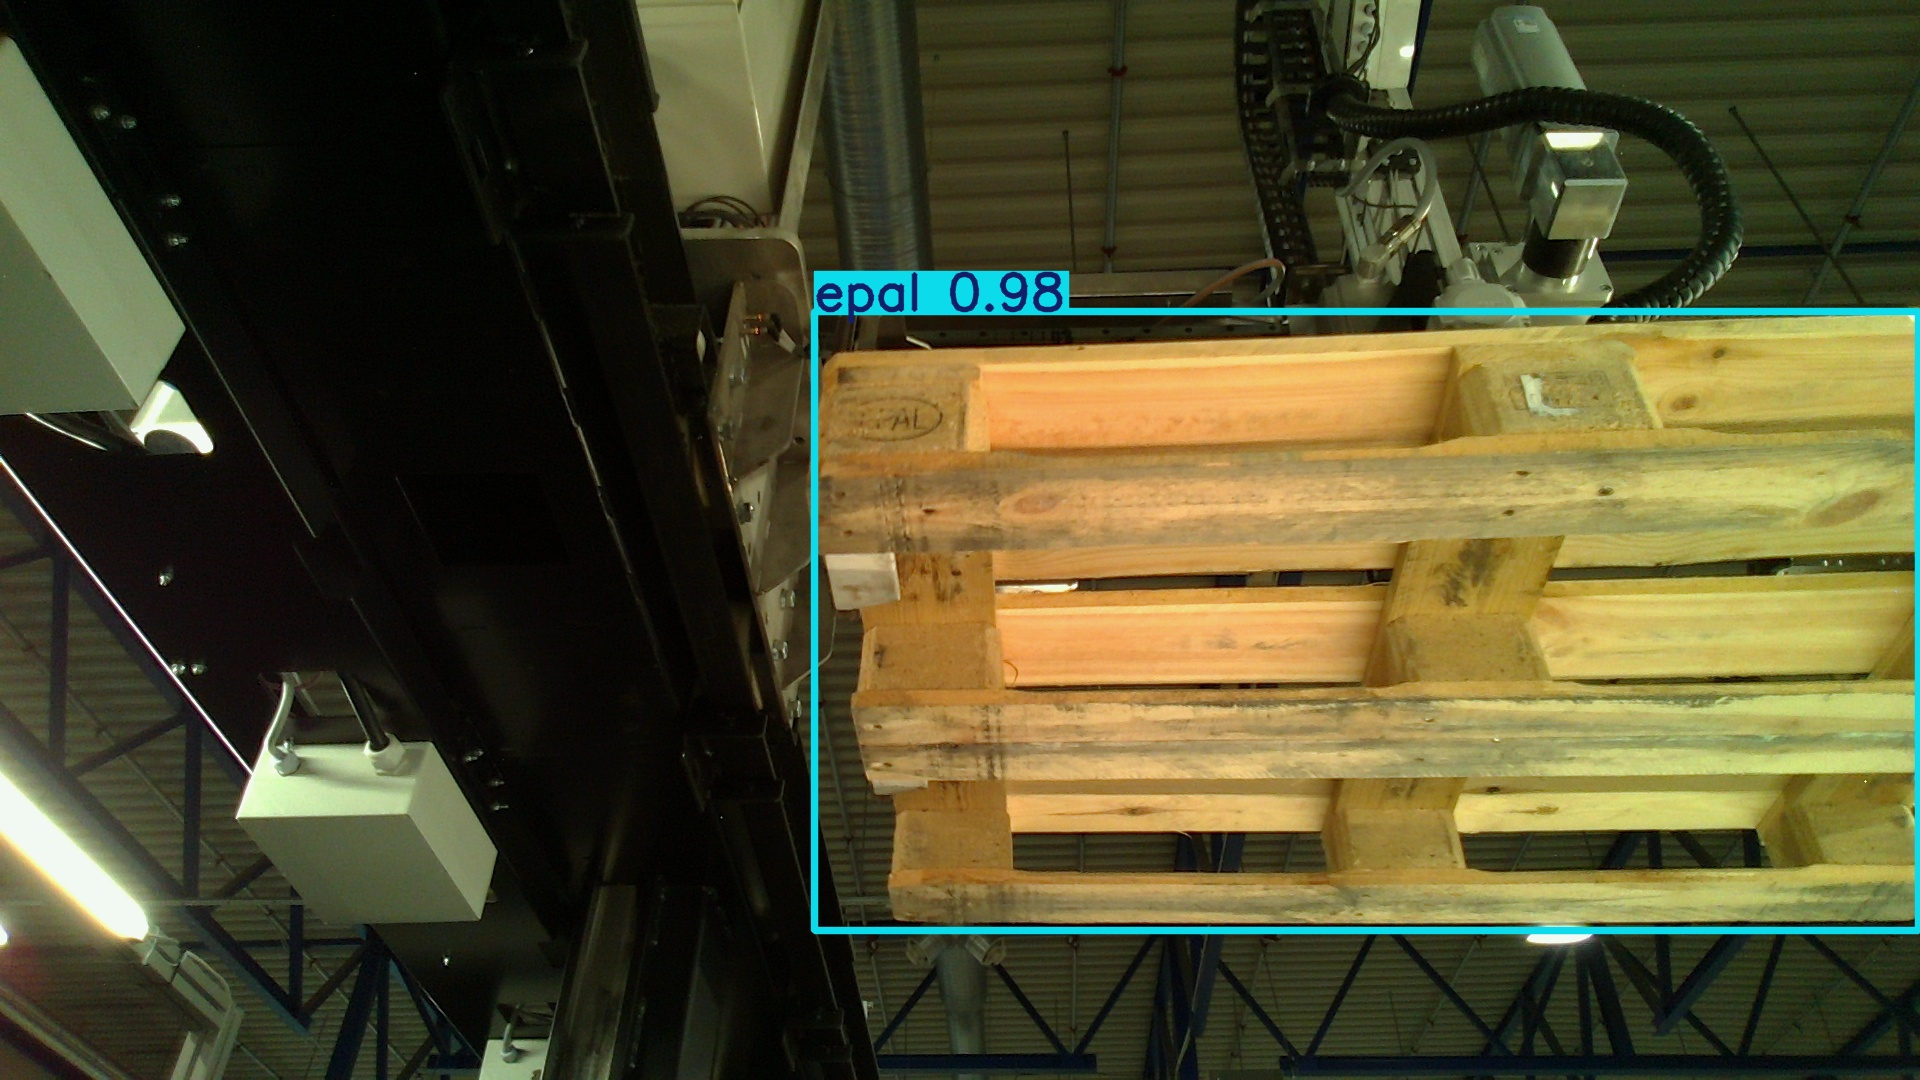

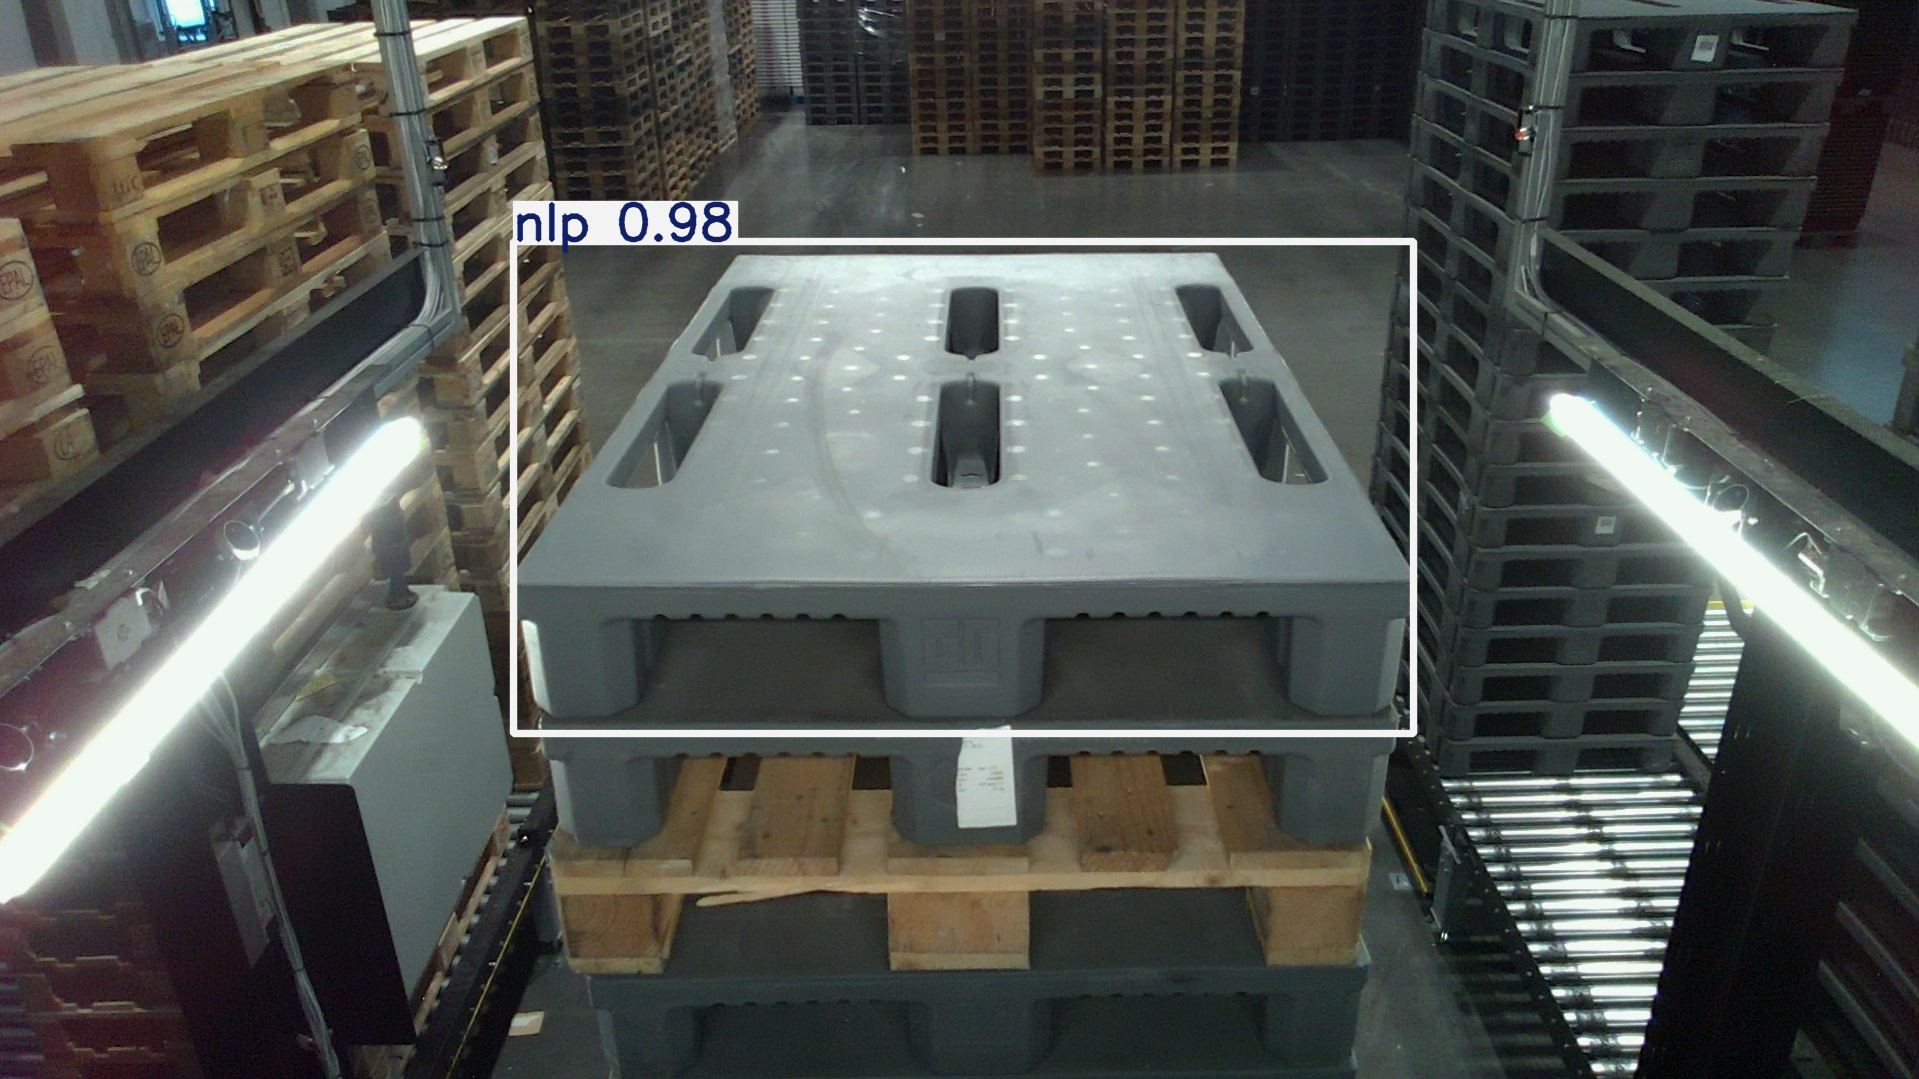

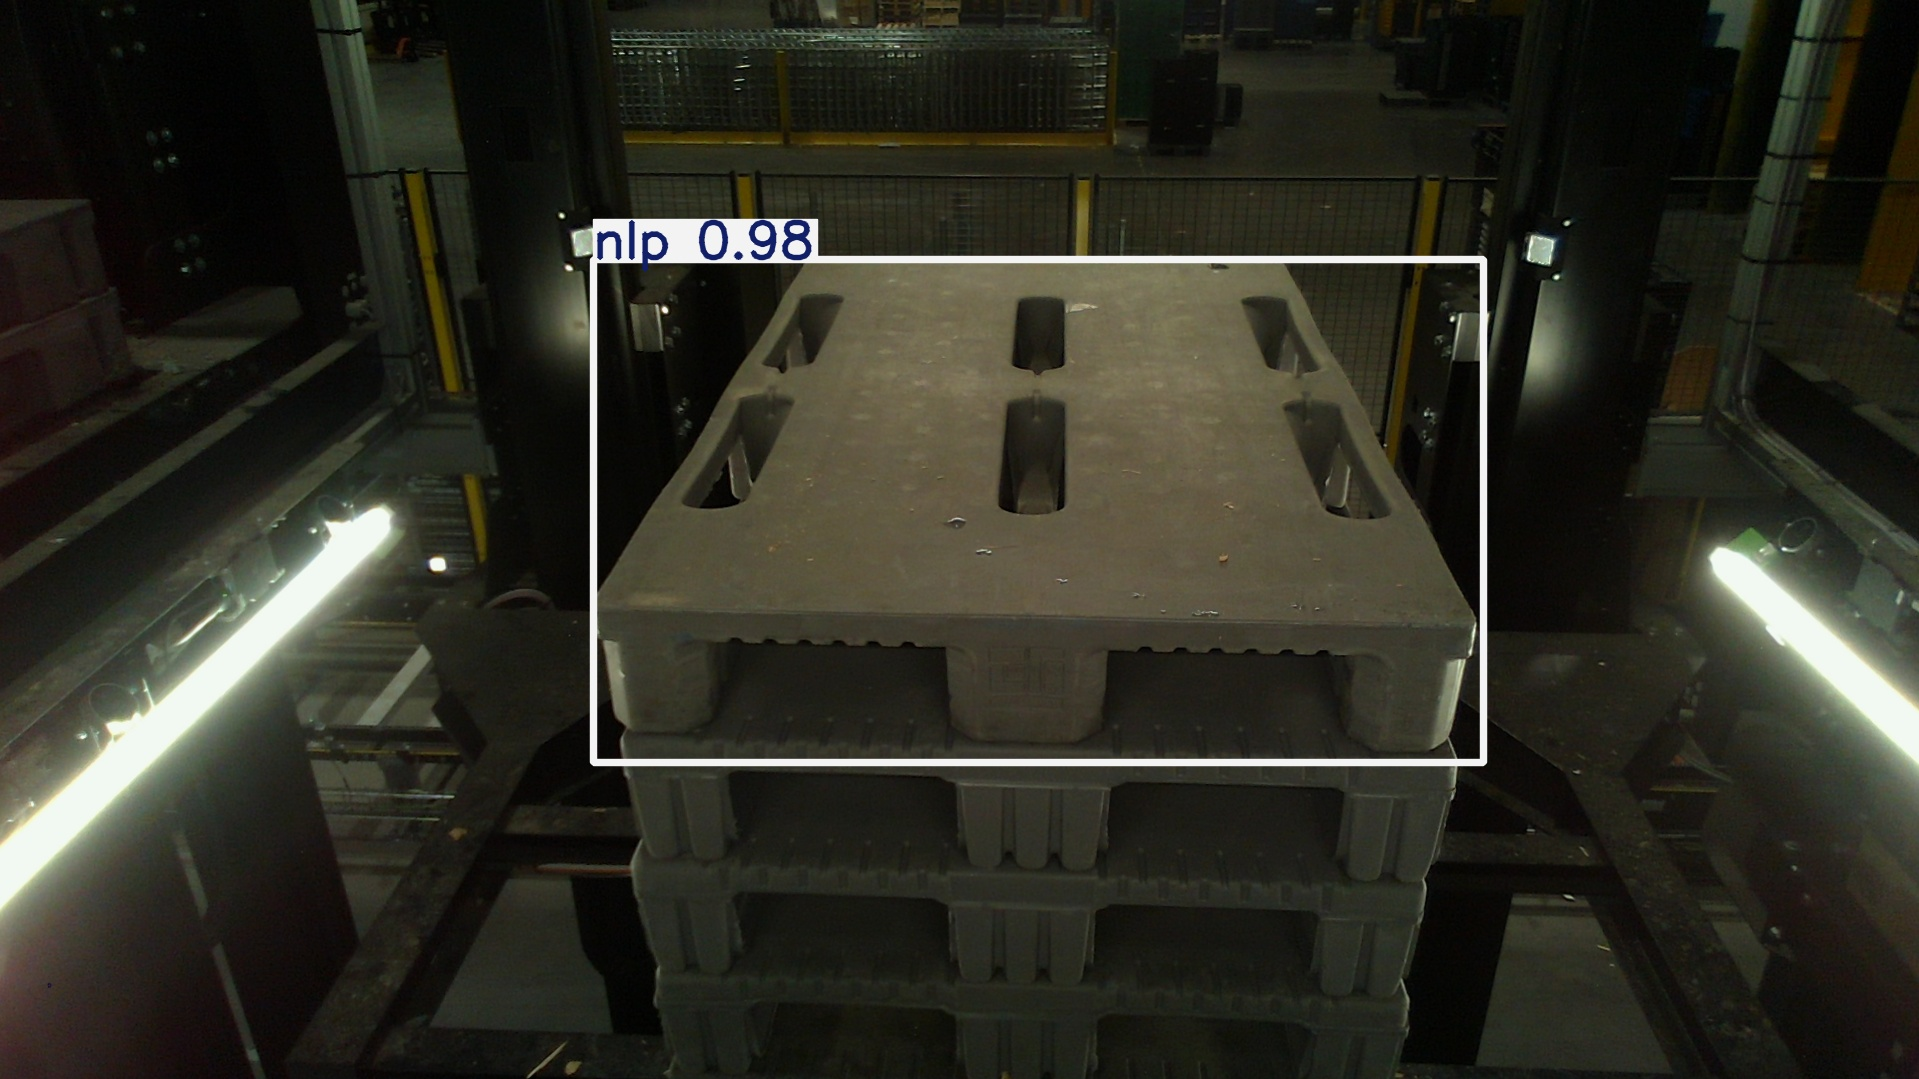

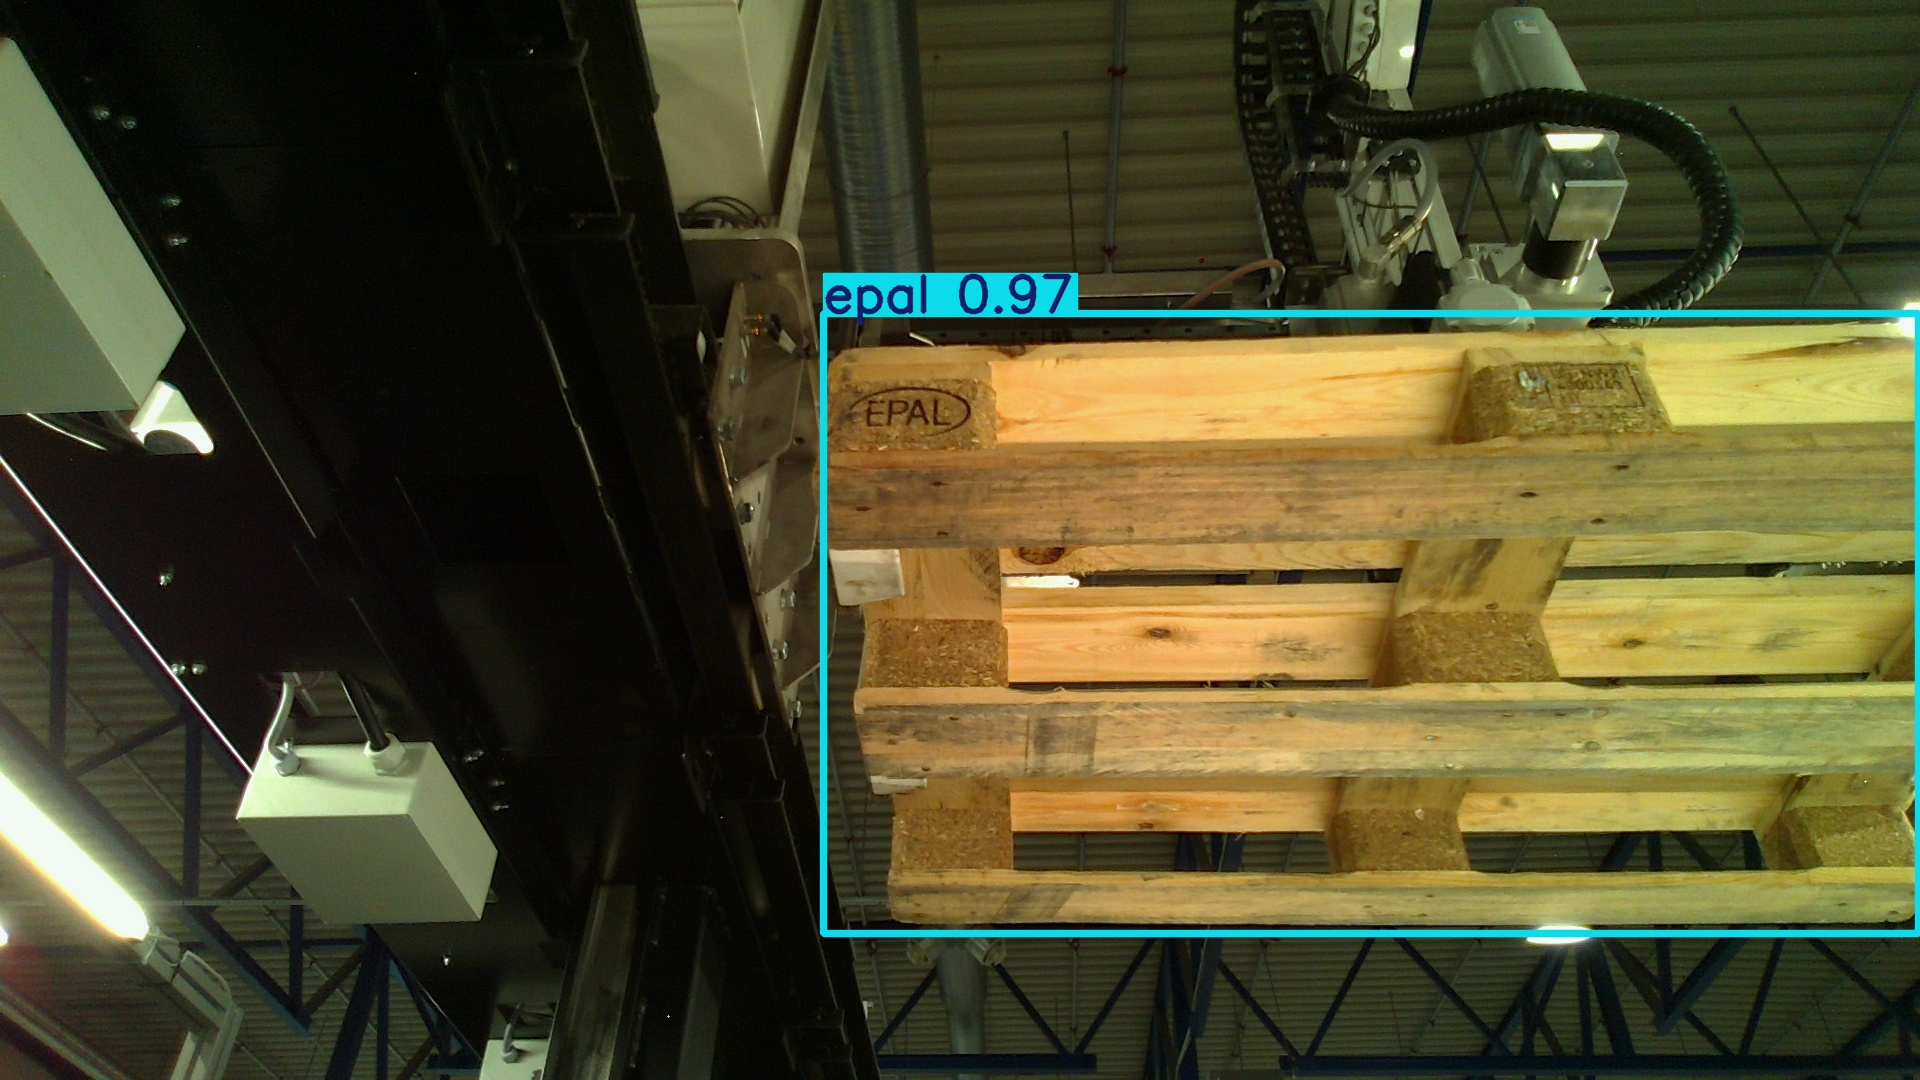

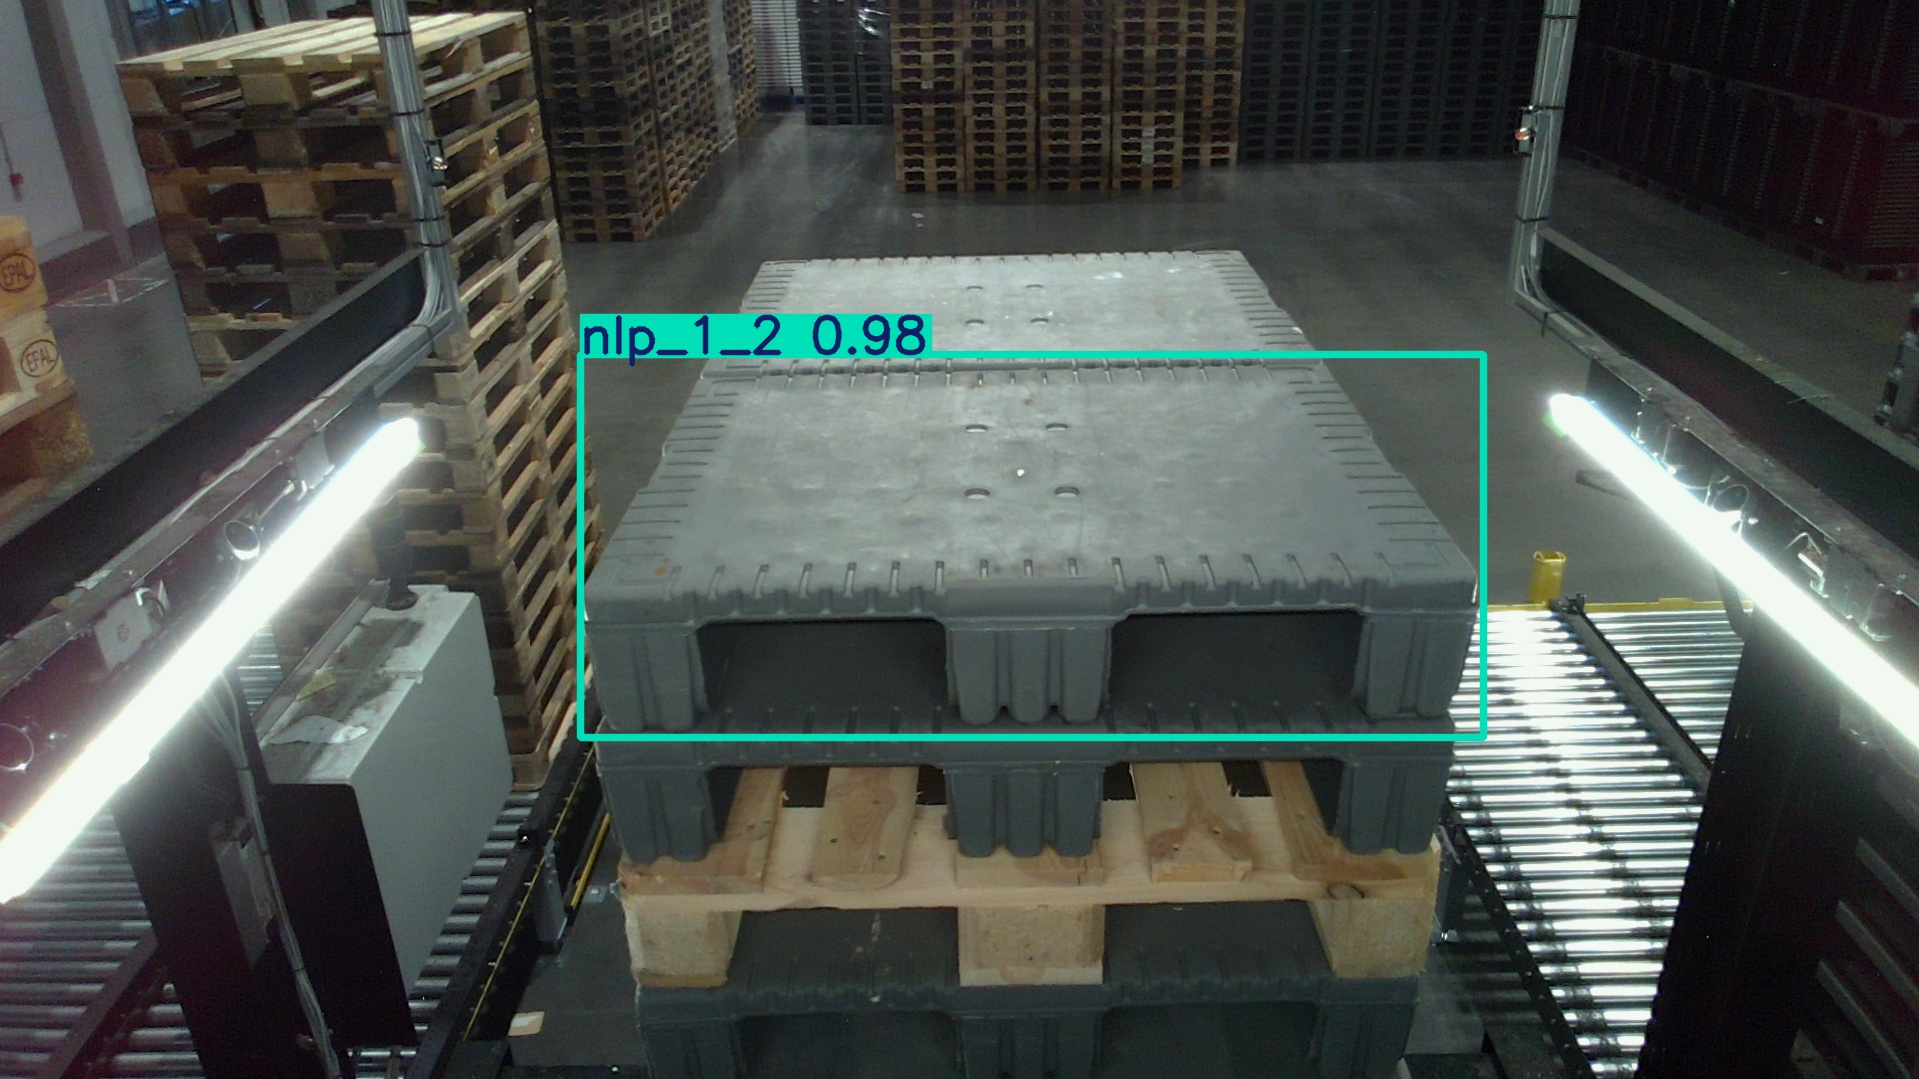

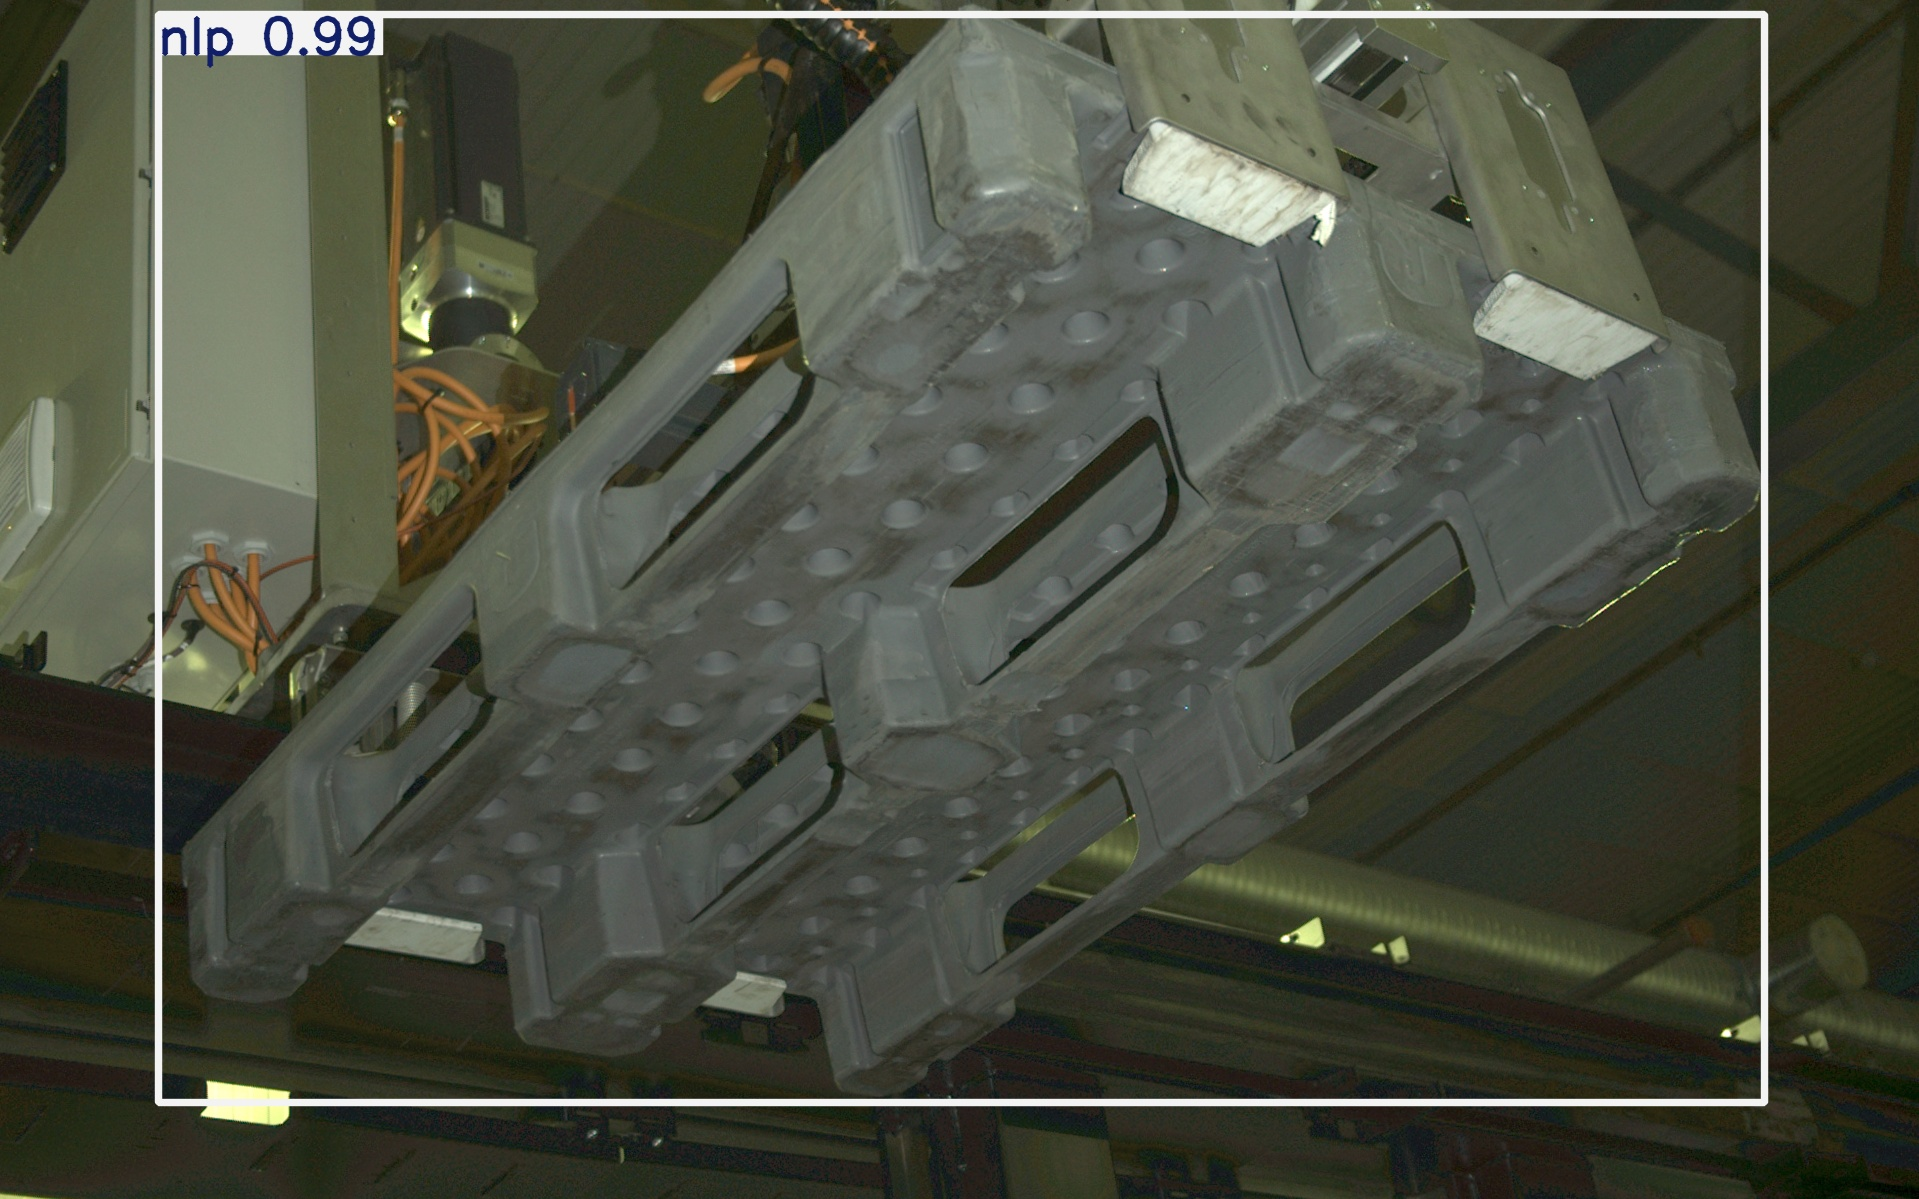

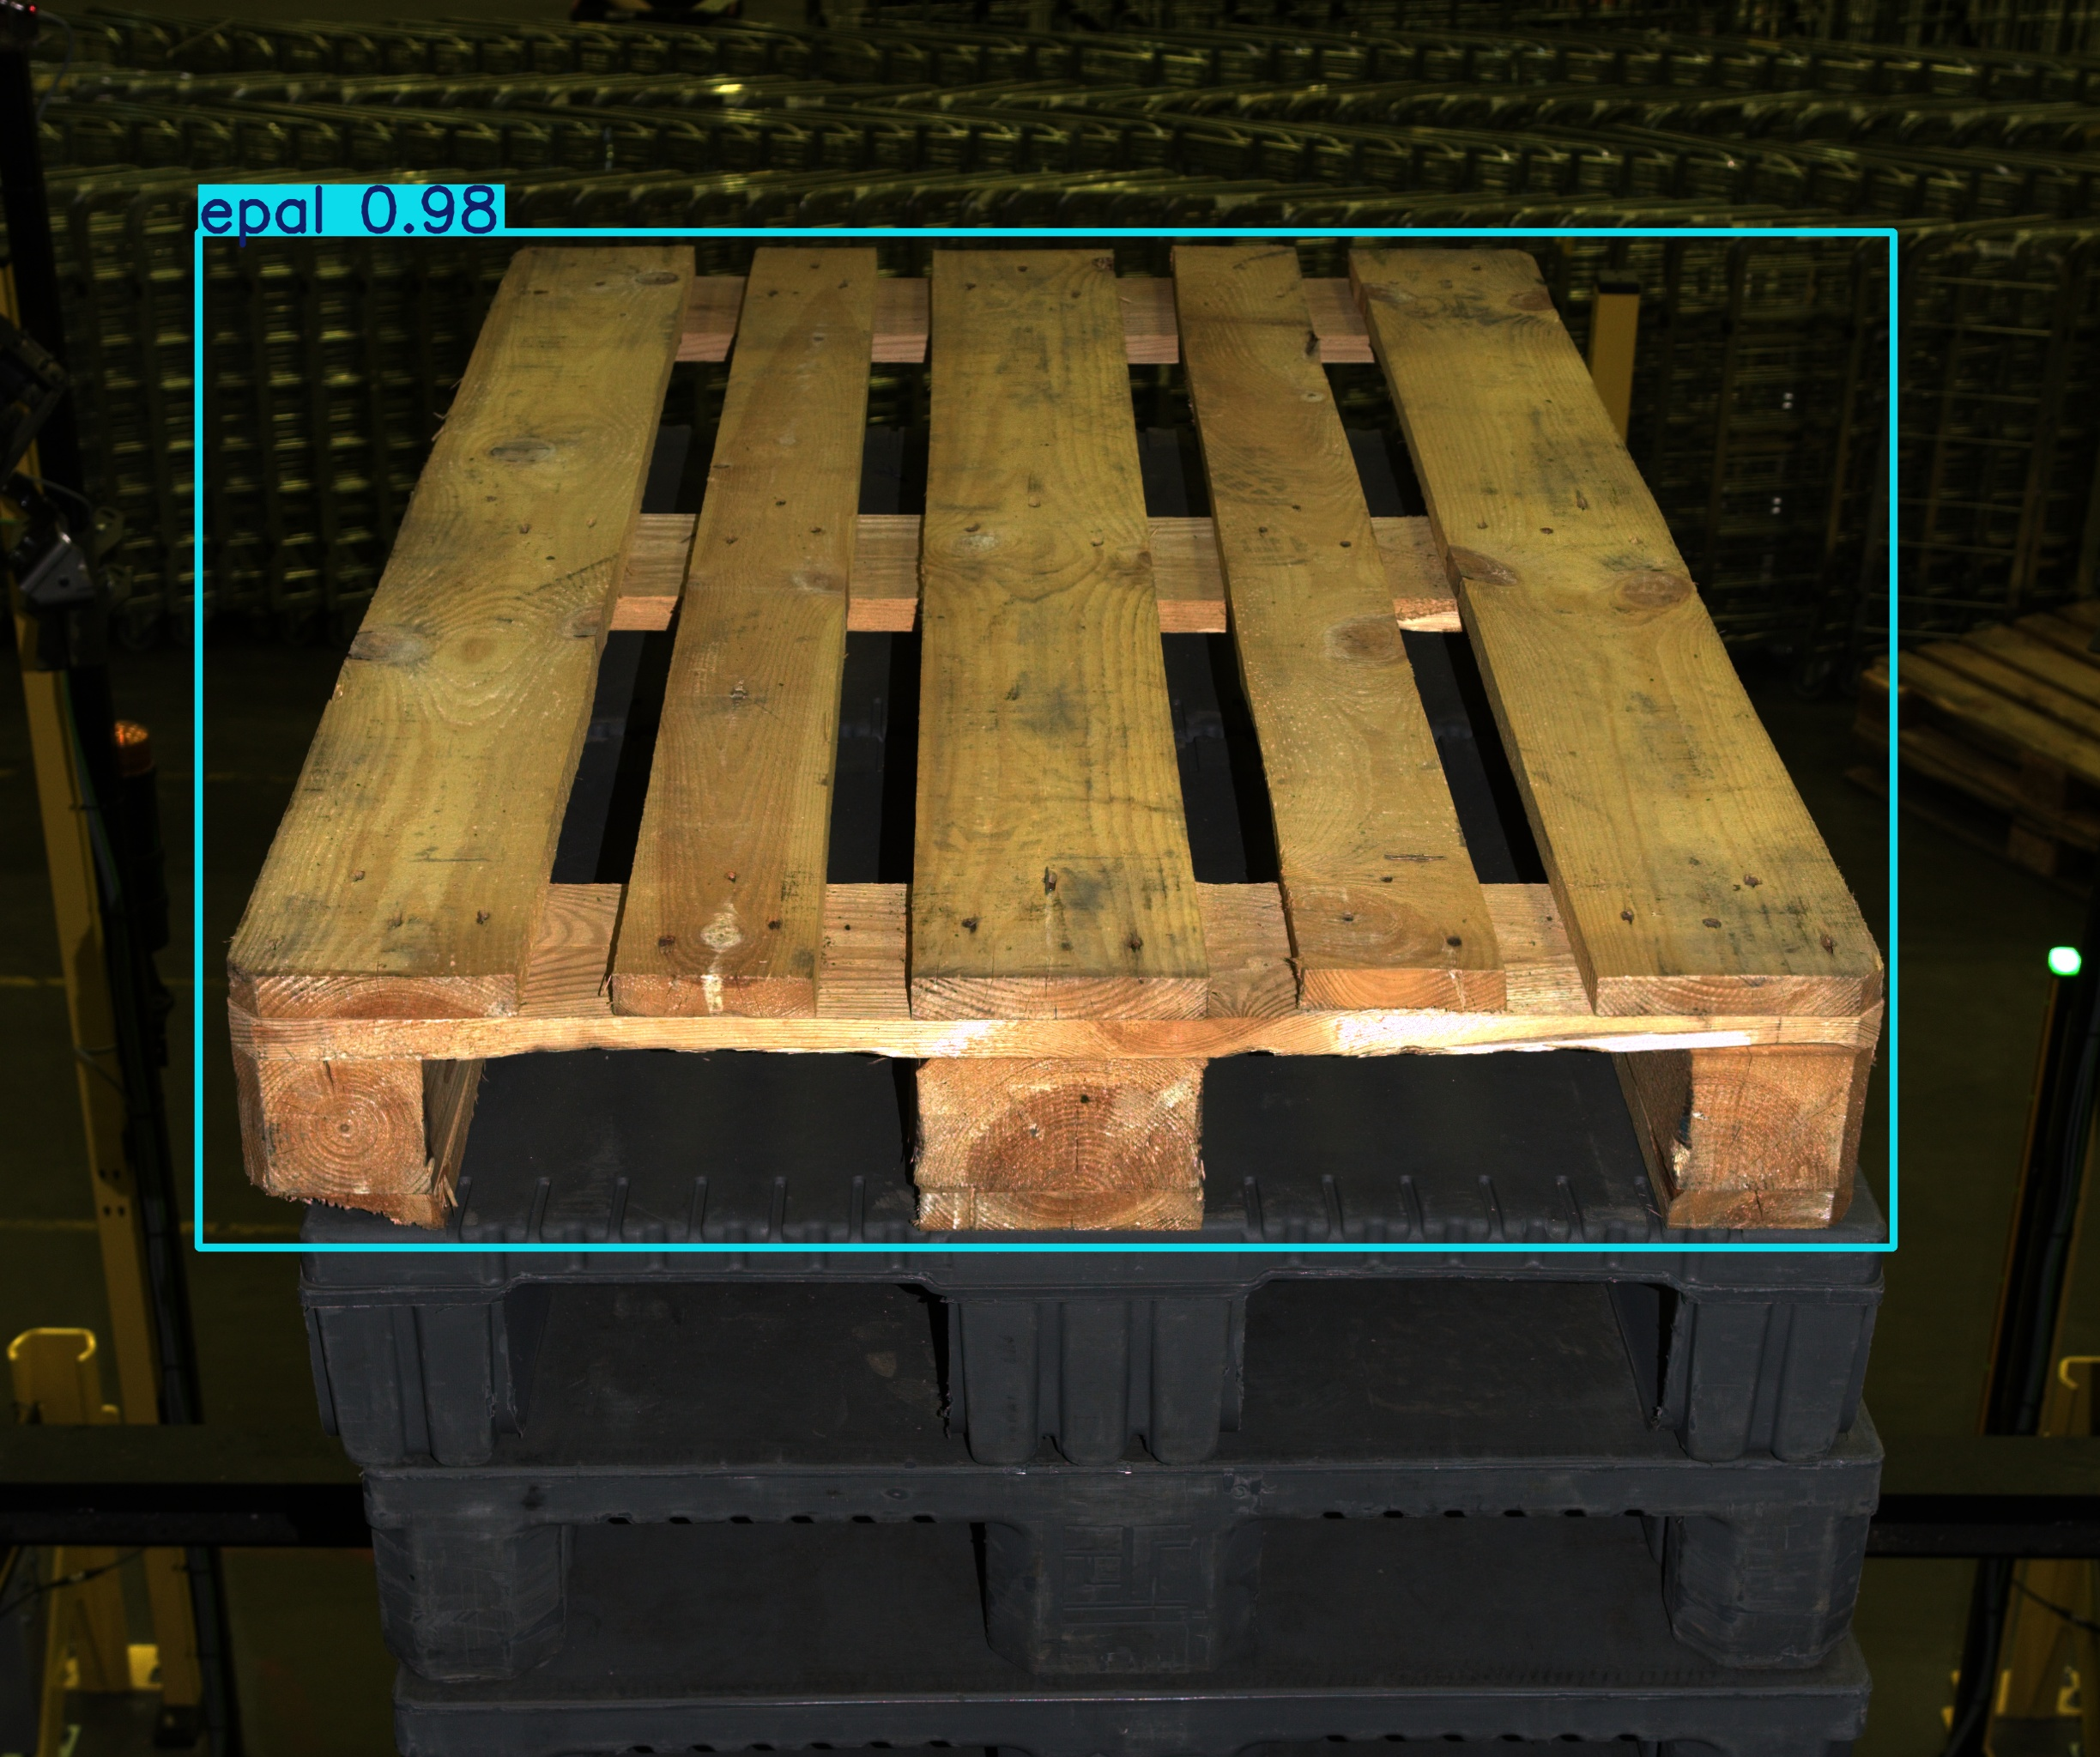

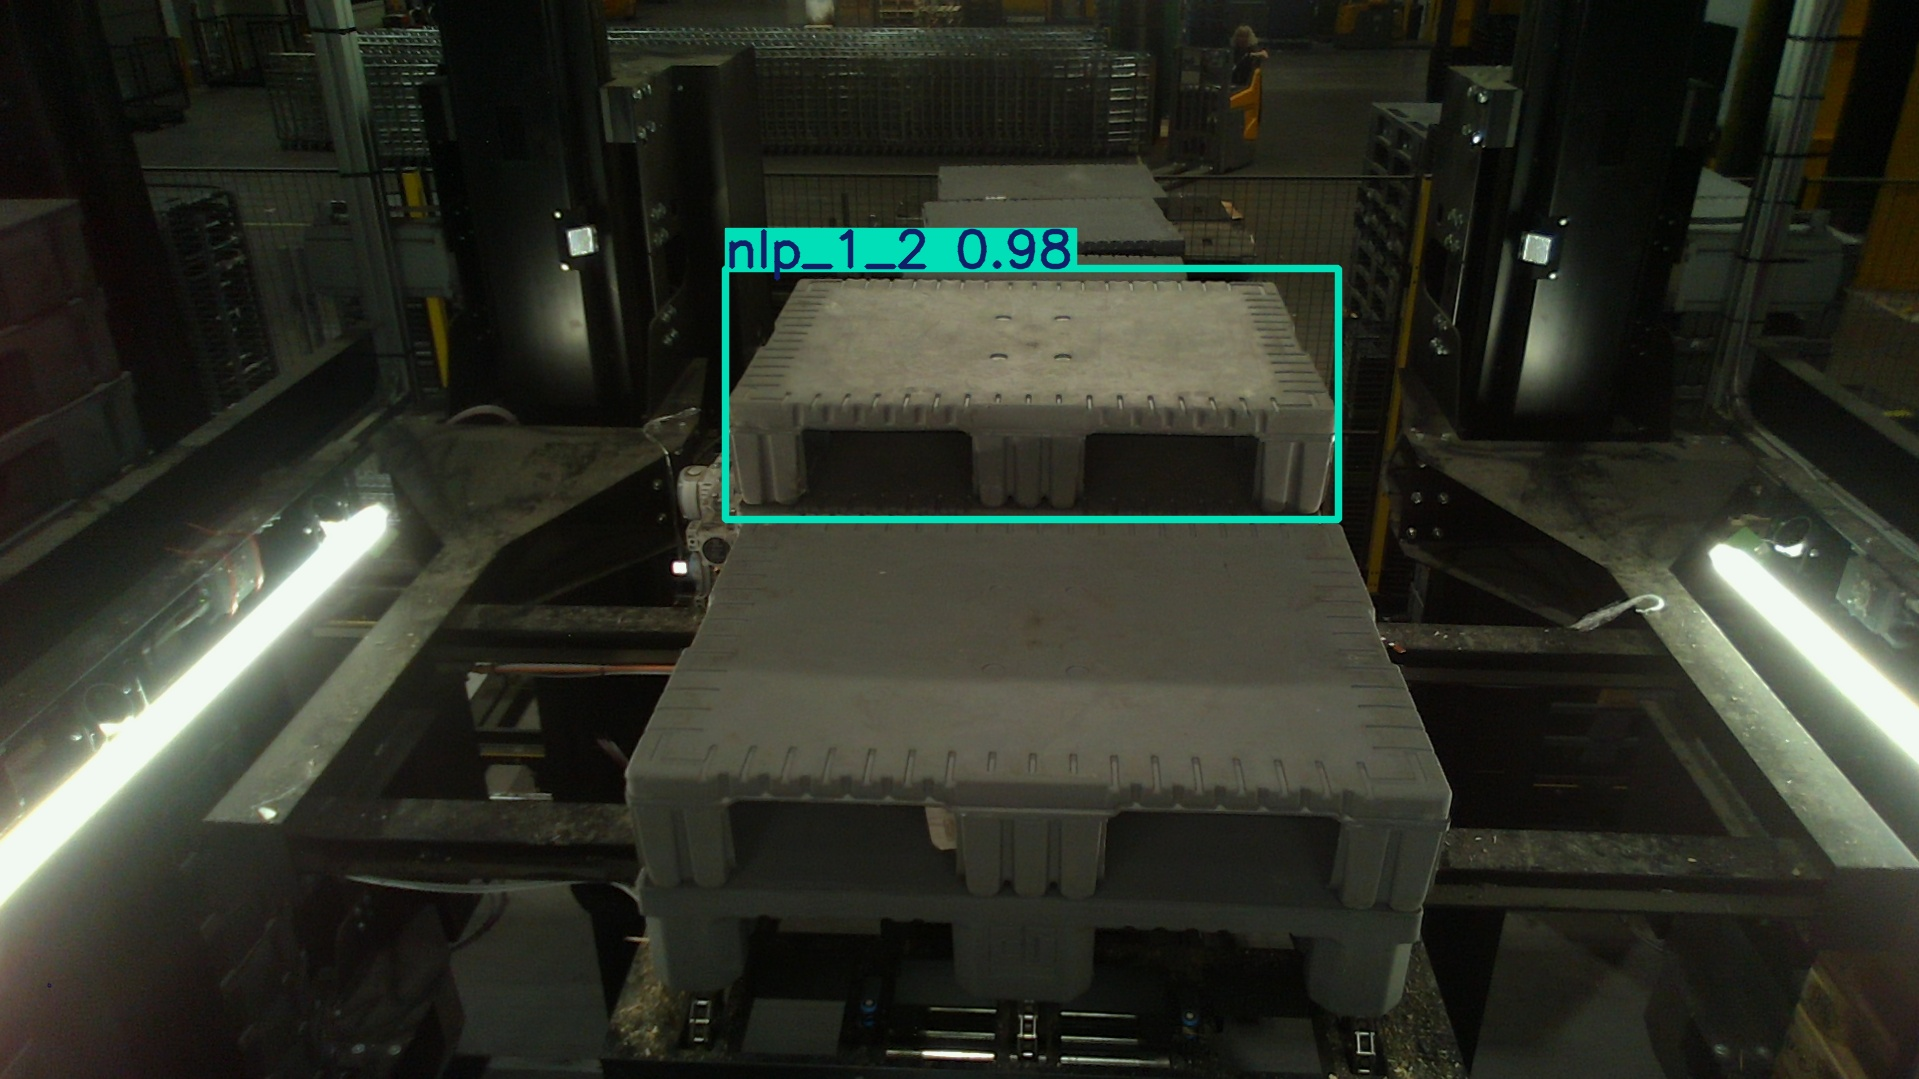

In [ ]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'runs/detect/predict3/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')


In [ ]:
from google.colab import files
model_path = '/content/runs/detect/train3/weights/best.pt'
if os.path.exists(model_path):
    files.download(model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>